In [1]:
import os
os.chdir(os.path.join(os.getcwd(), '..'))
os.getcwd()


'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [91]:
from src.components.optuna_model_selection.lightning_modules import MRIDataModule, MRIModule
from src.constants.local import *
from src.components.optuna_model_selection.model import MRIFlexAttentionUNet, MRIFlexAttentionUNetGroupNorm

In [23]:
import torch
import torch.nn as nn
from torchvision.transforms import v2

In [13]:
state_dict = torch.load('last (3).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict = {
    k[len("model."):]: v for k, v in state_dict.items() if k.startswith("model.")
}

In [42]:
main_model = MRIFlexAttentionUNet(3,64,3,4,1,1,[5,3,3,5,3,5,3,3])
main_model.load_state_dict(inner_state_dict)
dataset = MRIDataModule(TRAIN_CSV, DEV_CSV, TEST_CSV, batch_size = 16, num_workers=10, train_empty_mri_ratio= 1,
                        dev_transform=v2.Compose([
            v2.Resize(256),
            v2.CenterCrop(256)
            ]))
dataset.setup()
dataloader = dataset.val_dataloader()



In [35]:

class F1Calibrator(nn.Module):
    """Learns per-channel scale + bias on logits from a frozen model,
    optimized against a differentiable soft-F1 surrogate."""
    def __init__(self, num_channels=3):
        super().__init__()
        self.scale = nn.Parameter(torch.ones(num_channels))
        self.bias = nn.Parameter(torch.zeros(num_channels))

    def forward(self, logits):
        # logits: (B, C, H, W) from the frozen main model
        adjusted = logits * self.scale.view(1, -1, 1, 1) + self.bias.view(1, -1, 1, 1)
        return torch.sigmoid(adjusted)

def soft_f1_loss(probs, targets, eps=1e-7):
    # probs, targets: (B, C, H, W) -> per-channel soft F1, then mean over channels
    probs = probs.flatten(2)      # (B, C, N)
    targets = targets.flatten(2).float()

    tp = (probs * targets).sum(dim=(0, 2))
    fp = (probs * (1 - targets)).sum(dim=(0, 2))
    fn = ((1 - probs) * targets).sum(dim=(0, 2))

    soft_f1 = 2 * tp / (2 * tp + fp + fn + eps)   # (C,)
    return 1 - soft_f1.mean()

In [47]:
import numpy as np

In [49]:
main_model.eval()
for p in main_model.parameters():
    p.requires_grad_(False)

calibrator = F1Calibrator(num_channels=3)
optimizer = torch.optim.Adam(calibrator.parameters(), lr=1e-4)
losses_max = []

for i in range(1):
    for j, batch in enumerate(dataloader):  
        images,  masks = batch
        if torch.sum(masks) == 0:
            with torch.no_grad():
                logits = main_model(images)
            #probs = calibrator(logits)
            probs = torch.sigmoid(logits)
            #loss = torch.sum(probs)/len(probs.view(-1))
            #loss = soft_f1_loss(probs, masks)
            loss = torch.max(probs)
        
        
        #optimizer.zero_grad()
        #loss.backward()
        #optimizer.step()
        
            losses_max.append(loss)
        
        print(j)
        #losses.append(loss)
    #print(np.sum(losses)/len(losses))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [ ]:
k = 0
for j, batch in enumerate(dataloader):  
    if j < 10:
        image, mask = batch
        print(image.shape, mask.shape)
    

torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])
torch.Size([16, 3, 310, 360]) torch.Size([16, 3, 310, 360])


In [45]:
len(losses)

49

In [48]:
np.mean(losses)

np.float32(0.0016999969)

In [52]:
import pandas as pd
df = pd.read_csv(DEV_CSV)
len(df[df.empty_slice])/len(df)

0.5682870370370371

In [53]:
max(losses_max)

tensor(1.0000)

In [54]:
min(losses_max)

tensor(5.4237e-07)

In [55]:
np.mean(losses_max)

np.float32(0.28497937)

In [ ]:
tp = out*mask
fn = out * (1- mask)

array([[[ 3, 25,  3],
        [ 3, 25,  3]],

       [[ 3, 25,  3],
        [ 3, 25,  3]]])

In [ ]:
[0,1,1]

False

In [265]:
def get_distribution(model, dataloader):

    num_channels = 3

    dist_pos = np.zeros((num_channels, 100001), dtype=np.int64)  
    dist_neg = np.zeros((num_channels, 100001), dtype=np.int64)  

    model.eval()
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            inp, mask = batch
            out = torch.sigmoid(model(inp))  

            for c in range(num_channels):
                probs_c = out[:, c].reshape(-1)
                mask_c = mask[:, c].reshape(-1)

                pos_vals = probs_c[mask_c == 1]
                neg_vals = probs_c[mask_c == 0]

                pos_bins = (pos_vals * 100000).round().type(torch.int64).cpu().numpy()
                neg_bins = (neg_vals * 100000).round().type(torch.int64).cpu().numpy()

                dist_pos[c] += np.bincount(pos_bins, minlength=100001)
                dist_neg[c] += np.bincount(neg_bins, minlength=100001)
            print(i)

    return dist_pos, dist_neg

In [266]:
dist_pos, dist_neg = get_distribution(main_model, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [70]:
10e3+1

10001.0

In [81]:
import matplotlib.pyplot as plt


In [271]:
from scipy.ndimage import gaussian_filter1d

def plot_smooth_distributions(dist_pos, dist_neg, sigma=50, left_x_lim = 0, right_x_lim = 1, threshold = None):
    
    x = np.linspace(0, 1, 100001)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    channel_names = ['small bowel', 'large bowel', 'stomach']
    #rat = np.max(dist_pos, 1)/np.max(dist_neg, 1)
    #dist_neg = dist_neg * rat[:, None]
    for c in range(3):
        ax = axes[c]
        if sigma == 0:
            smooth_pos = dist_pos[c].astype(float)
            smooth_neg = dist_neg[c].astype(float)

        else:
            smooth_pos = gaussian_filter1d(dist_pos[c].astype(float), sigma=sigma)
            smooth_neg = gaussian_filter1d(dist_neg[c].astype(float), sigma=sigma)
        
        # 2. Plot the solid outer lines
        ax.plot(x, smooth_pos, label='Foreground', color='red', linewidth=2)
        ax.plot(x, smooth_neg, label='Background', color='blue', linewidth=2)
        if threshold is not None:
            ax.axvline(x = threshold[c], label = 'Threshold', color = 'green', linewidth = 1)
        
        # 3. Fill the area underneath the curves for readability
        ax.fill_between(x, smooth_pos, alpha=0.2, color='red')
        ax.fill_between(x, smooth_neg, alpha=0.2, color='blue')
        
        # Formatting
        ax.set_title(f'{channel_names[c]}', fontsize=14, fontweight='bold')
        ax.set_xlabel('Predicted Probability', fontsize=12)
        ax.set_ylabel('Smoothed Pixel Count', fontsize=12)
        
        # Keep the log scale to view massive background counts and tiny foreground counts simultaneously
        ax.set_yscale('log')
        ax.set_xlim(left_x_lim, right_x_lim)
        
        # Force the bottom limit to 1 to prevent log(0) visual artifacts at the bottom of the chart
        ax.set_ylim(bottom=1) 
        
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend(loc='best')
        
    plt.tight_layout()
    plt.show()

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002527F12EFC0>
Traceback (most recent call last):
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1650, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002527F12EFC0>
Traceback (most recent call last):
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "d:\learning\learning\programing\portfolio_projects\1_image\venv\Lib\site

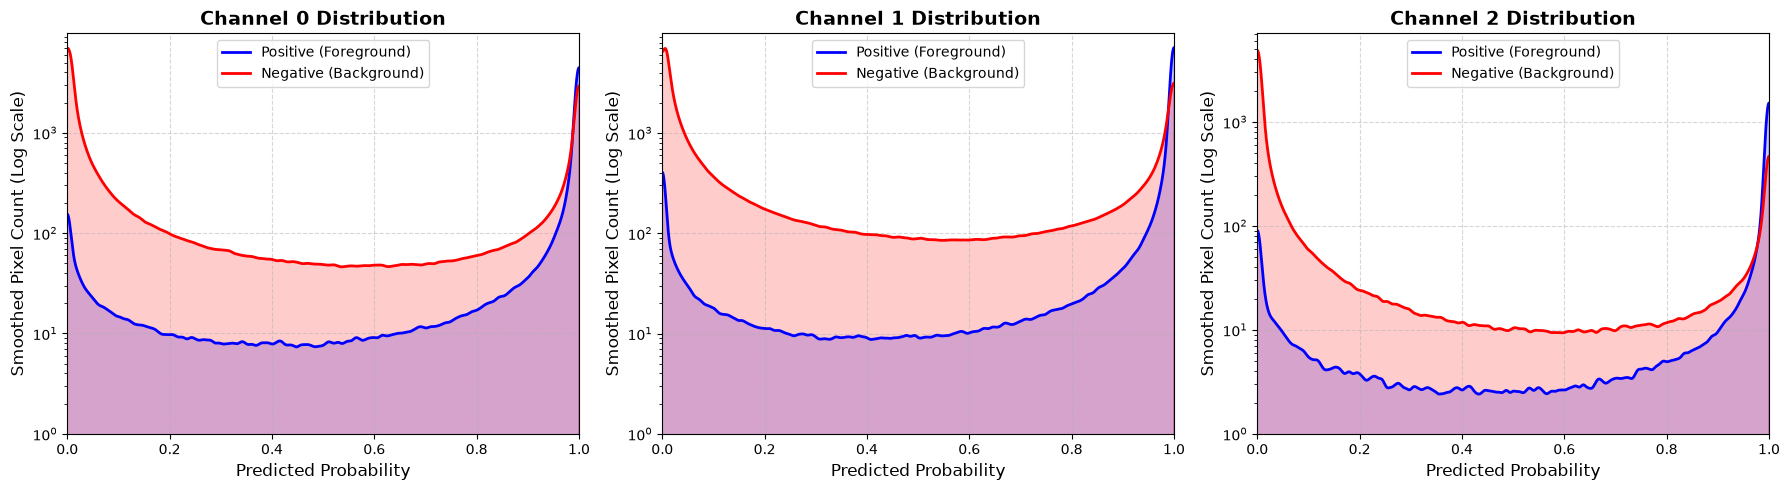

In [ ]:
#plot_smooth_distributions(dist_pos, dist_neg)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

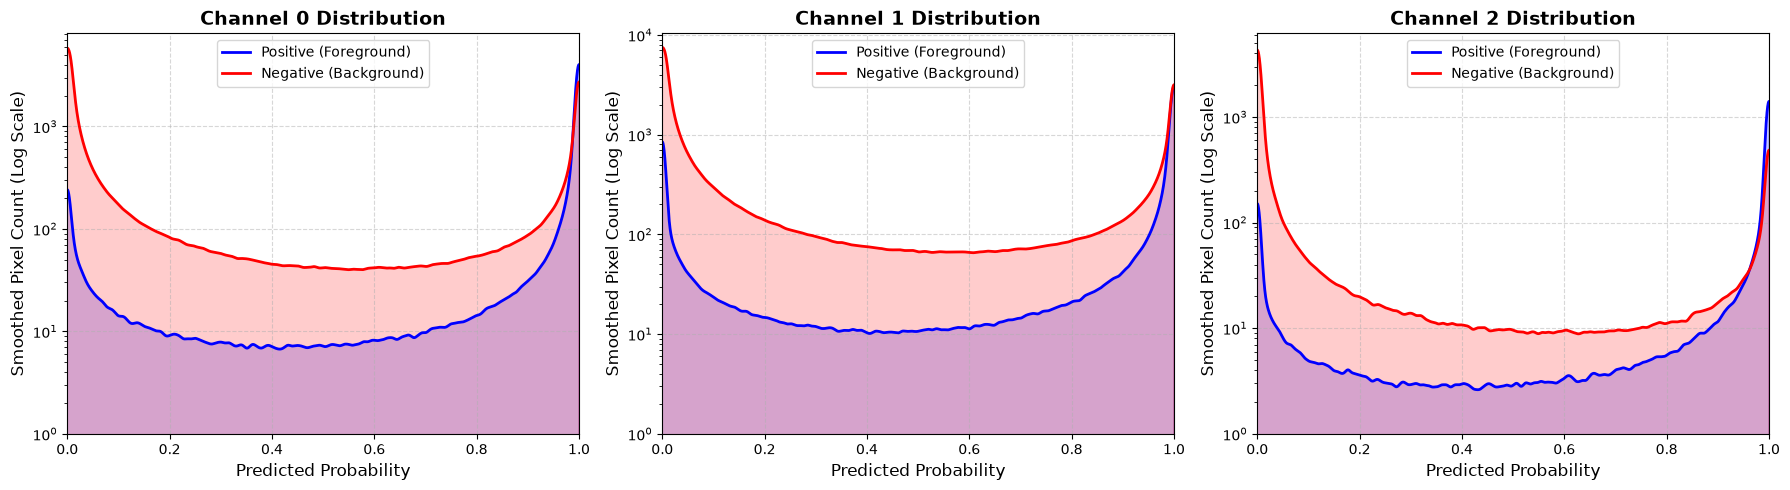

In [ ]:
state_dict_2 = torch.load('model-epoch=29-val_loss=0.42.ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_2 = {
    k[len("model."):]: v for k, v in state_dict_2.items() if k.startswith("model.")
}

main_model_2 = MRIFlexAttentionUNetGroupNorm(3,64,3,5,1,1,[5,3,3,3,3,3,3,3,3,5])
main_model_2.load_state_dict(inner_state_dict_2)

#dist_pos_2, dist_neg_2 = get_distribution(main_model_2, dataloader)

#plot_smooth_distributions(dist_pos_2, dist_neg_2)


dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

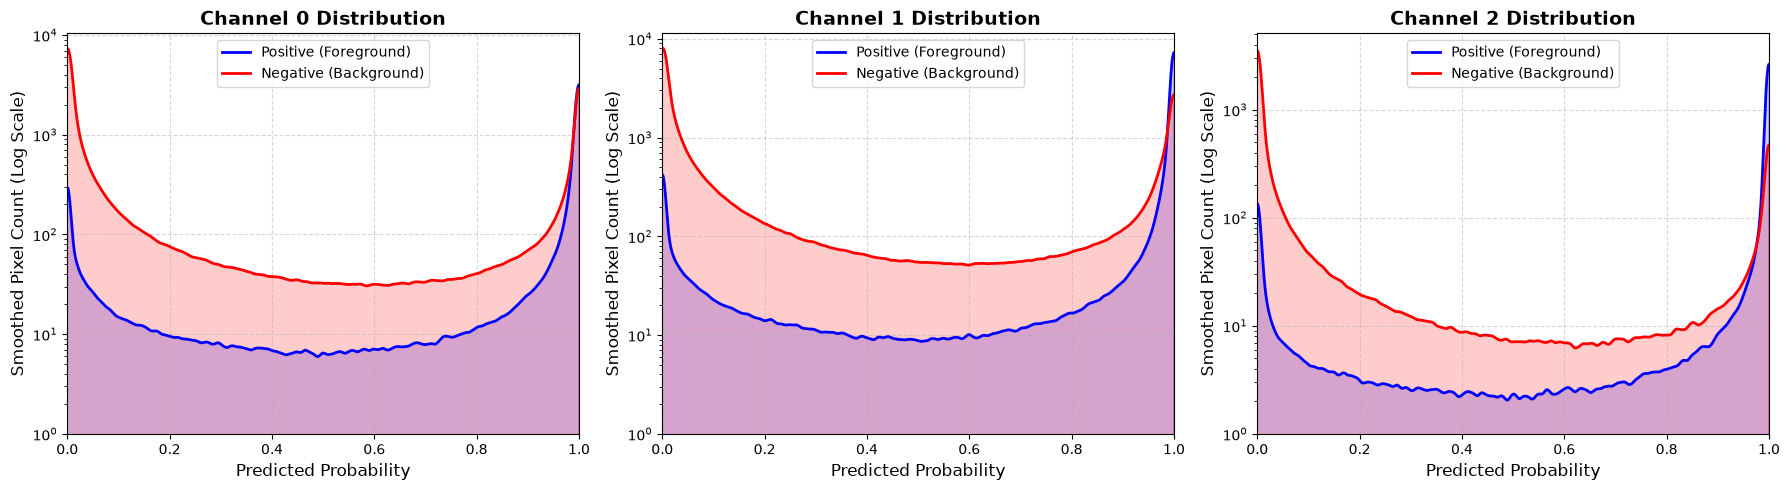

In [ ]:
state_dict_3 = torch.load('model-epoch=43-val_loss=0.37.ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_3 = {
    k[len("model."):]: v for k, v in state_dict_3.items() if k.startswith("model.")
}

main_model_3 = MRIFlexAttentionUNet(3,64,3,4,2,2,[5,3,3,5,3,3,3,3])
main_model_3.load_state_dict(inner_state_dict_3)

#dist_pos_3, dist_neg_3 = get_distribution(main_model_3, dataloader)

#plot_smooth_distributions(dist_pos_3, dist_neg_3)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

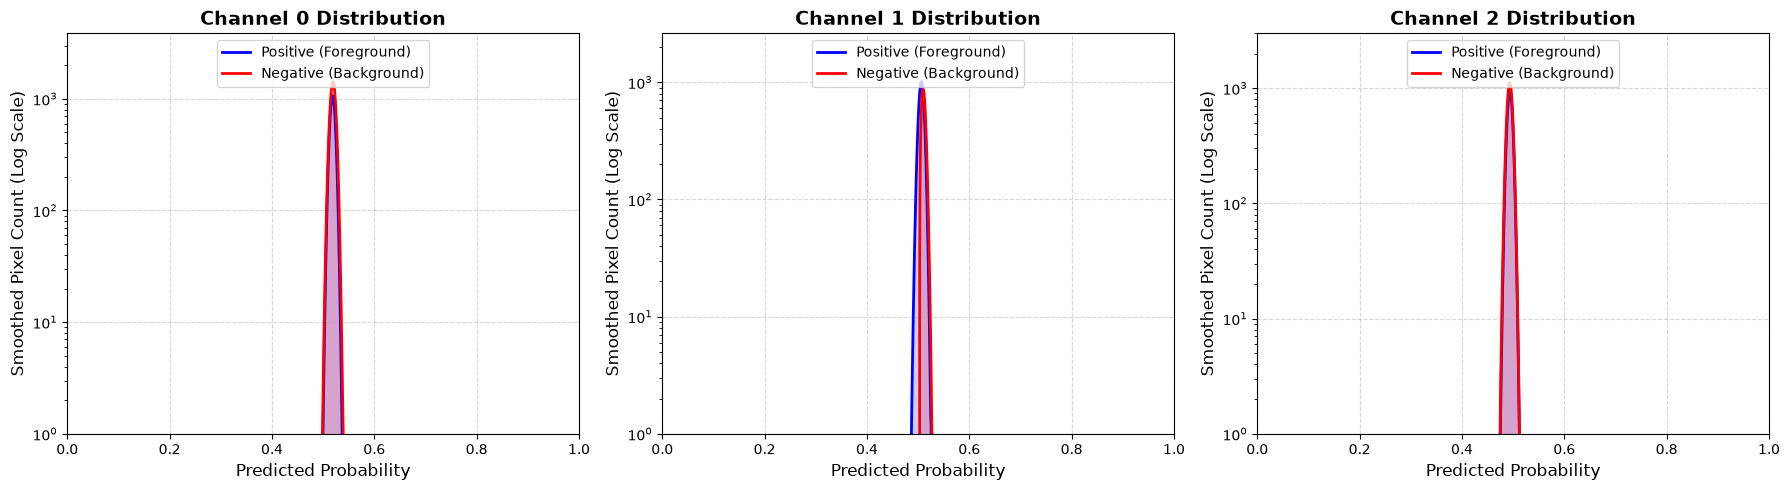

In [ ]:
state_dict_4 = torch.load('last (4).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_4 = {
    k[len("model."):]: v for k, v in state_dict_4.items() if k.startswith("model.")
}

main_model_4 = MRIFlexAttentionUNet(3,64,3,4,1,1,[5,3,3,5,3,5,3,3])
main_model.load_state_dict(inner_state_dict_4)

#dist_pos_4, dist_neg_4 = get_distribution(main_model_4, dataloader)

#plot_smooth_distributions(dist_pos_4, dist_neg_4)

dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadfjlksdaf
dfklsadf

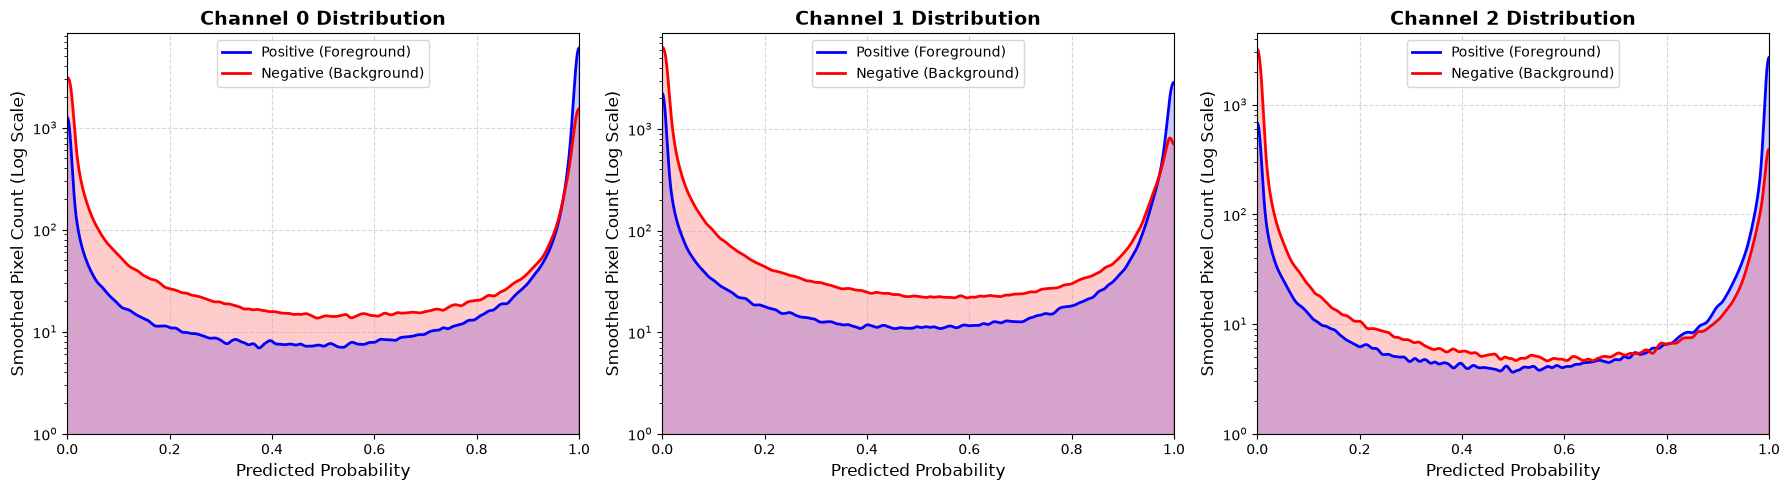

In [ ]:
state_dict_5 = torch.load('last (5).ckpt', 'cpu', weights_only=False)['state_dict']
inner_state_dict_5 = {
    k[len("model."):]: v for k, v in state_dict_5.items() if k.startswith("model.")
}

main_model_5 = MRIFlexAttentionUNet(3,64,3,4,2,2,[5,3,3,5,3,5,5,3])
main_model_5.load_state_dict(inner_state_dict_5)

#dist_pos_5, dist_neg_5 = get_distribution(main_model_5, dataloader)

#plot_smooth_distributions(dist_pos_5, dist_neg_5)

In [107]:
torch.load('last (5).ckpt', 'cpu', weights_only=False)


{'epoch': 3,
 'global_step': 2120,
 'pytorch-lightning_version': '2.6.6',
 'state_dict': OrderedDict([('model.encoder_list.0.conv_block.conv_block.0.0.weight',
               tensor([[[[ 2.4958e-02,  7.8226e-02, -7.6603e-02, -4.2811e-02,  7.3899e-02],
                         [ 6.0279e-02,  9.1242e-02,  9.0996e-02, -1.1765e-02, -5.6208e-02],
                         [ 4.6608e-02, -1.1431e-01, -7.3340e-02,  1.1632e-01,  1.5118e-02],
                         [-6.8893e-02,  3.4278e-02, -2.4972e-02, -7.9249e-02, -1.9506e-02],
                         [ 4.4834e-02,  8.1568e-02, -2.2766e-02, -6.1573e-02,  8.9855e-02]],
               
                        [[-1.2815e-01, -6.3358e-02,  8.0464e-03,  1.4025e-02,  8.3042e-02],
                         [ 5.2272e-03,  1.0486e-02, -1.0368e-01, -9.1802e-03, -1.9259e-02],
                         [-7.0462e-02, -3.4616e-02,  5.8964e-02,  3.6361e-02,  1.0092e-01],
                         [-1.4725e-02,  8.1841e-02, -6.8524e-02, -8.6404e-02, -4.1883e-

In [122]:
np.sum(dist_neg_2, 1, dtype=np.int64)

array([1896767, 2818843,  667820])

In [267]:
dist_pos_2, dist_neg_2 = get_distribution(main_model_2, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [268]:
dist_pos_3, dist_neg_3 = get_distribution(main_model_3, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [269]:
dist_pos_4, dist_neg_4 = get_distribution(main_model_4, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


In [270]:
dist_pos_5, dist_neg_5 = get_distribution(main_model_5, dataloader)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107


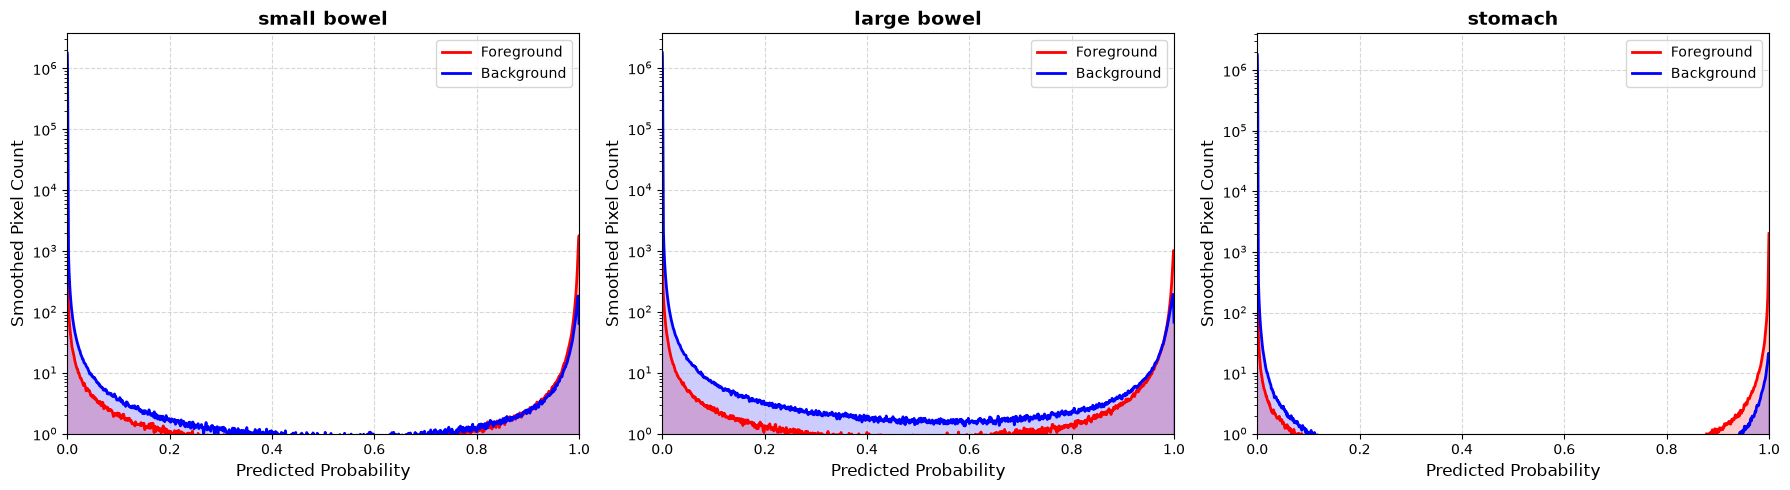

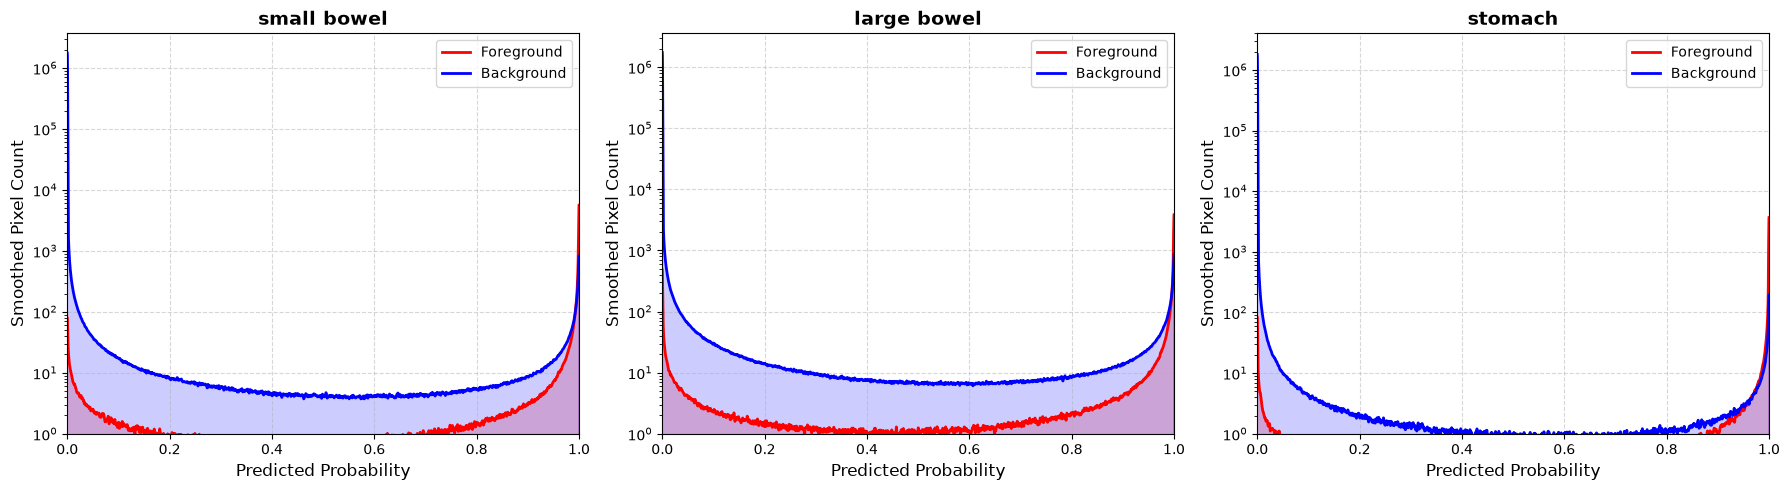

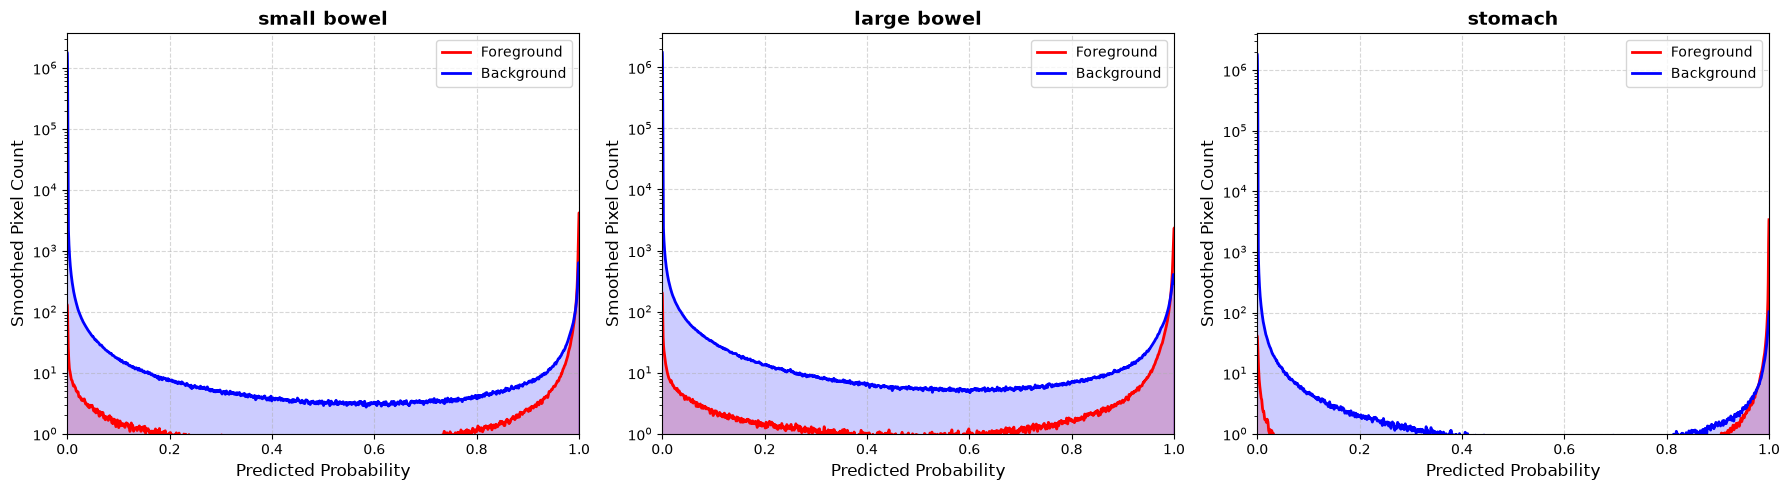

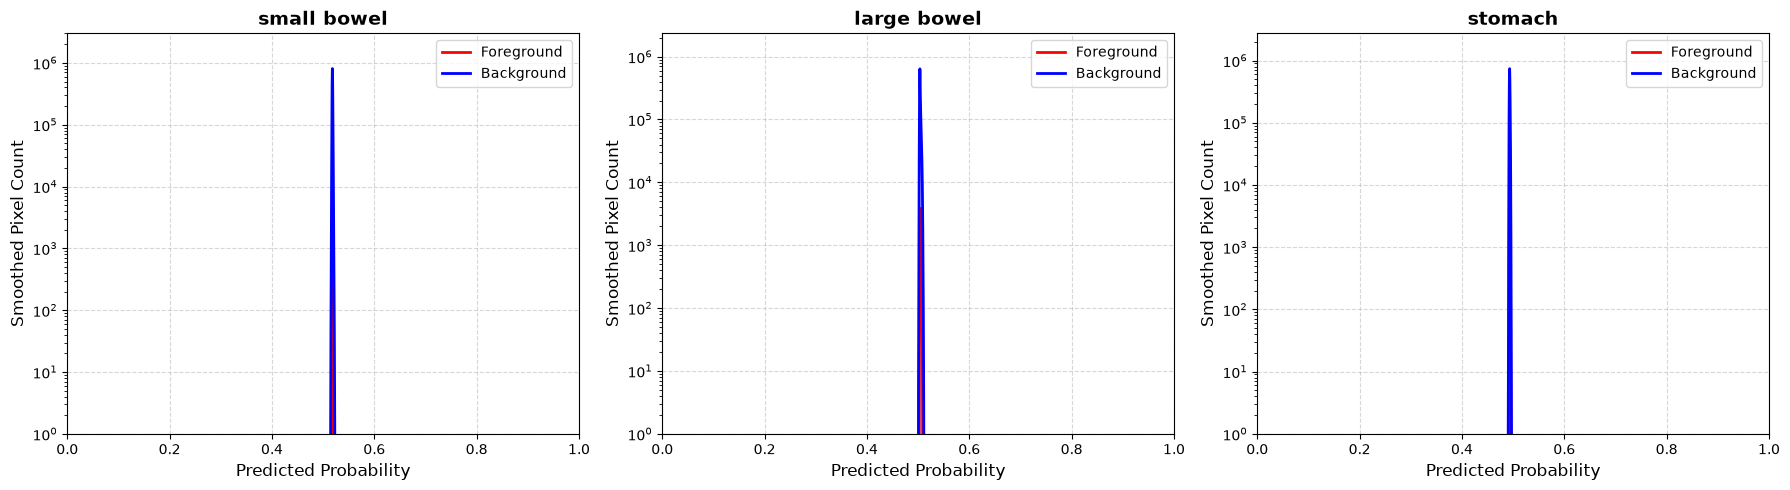

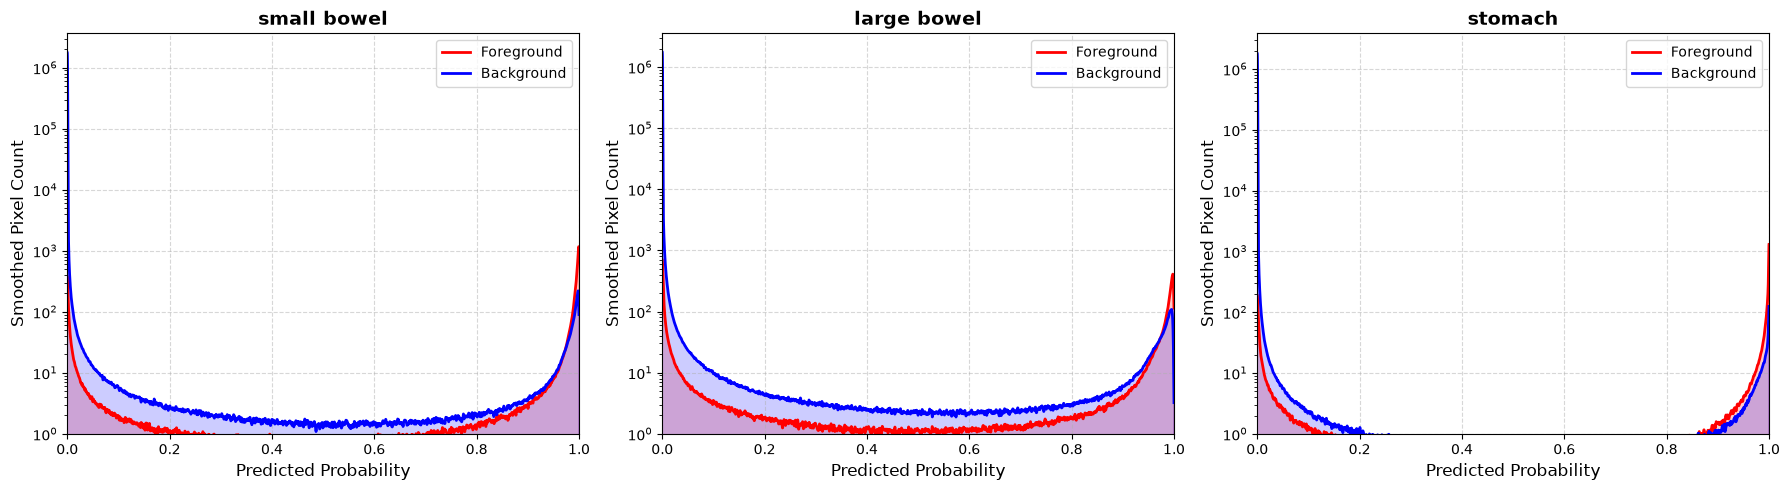

In [272]:
plot_smooth_distributions(dist_pos, dist_neg)
plot_smooth_distributions(dist_pos_2, dist_neg_2)
plot_smooth_distributions(dist_pos_3, dist_neg_3)
plot_smooth_distributions(dist_pos_4, dist_neg_4)
plot_smooth_distributions(dist_pos_5, dist_neg_5)

In [260]:
def get_partial_distribution(dist, neg_arr = False, ratio = [1,1,1]):
    ratio = np.array(ratio)
    lengths = np.sum(dist, axis=1)
    amounts_to_discard = np.round(lengths * ([1] - ratio))
    part_dist = np.copy(dist)
    if neg_arr:
        part_dist = np.flip(part_dist, 1)
    cum_sums = np.cumsum(part_dist, axis=1)
    mask_to_zero = cum_sums <= amounts_to_discard[:, None]
    
    part_dist[mask_to_zero] = 0
    if neg_arr:
        part_dist = np.flip(part_dist, 1)
    return part_dist

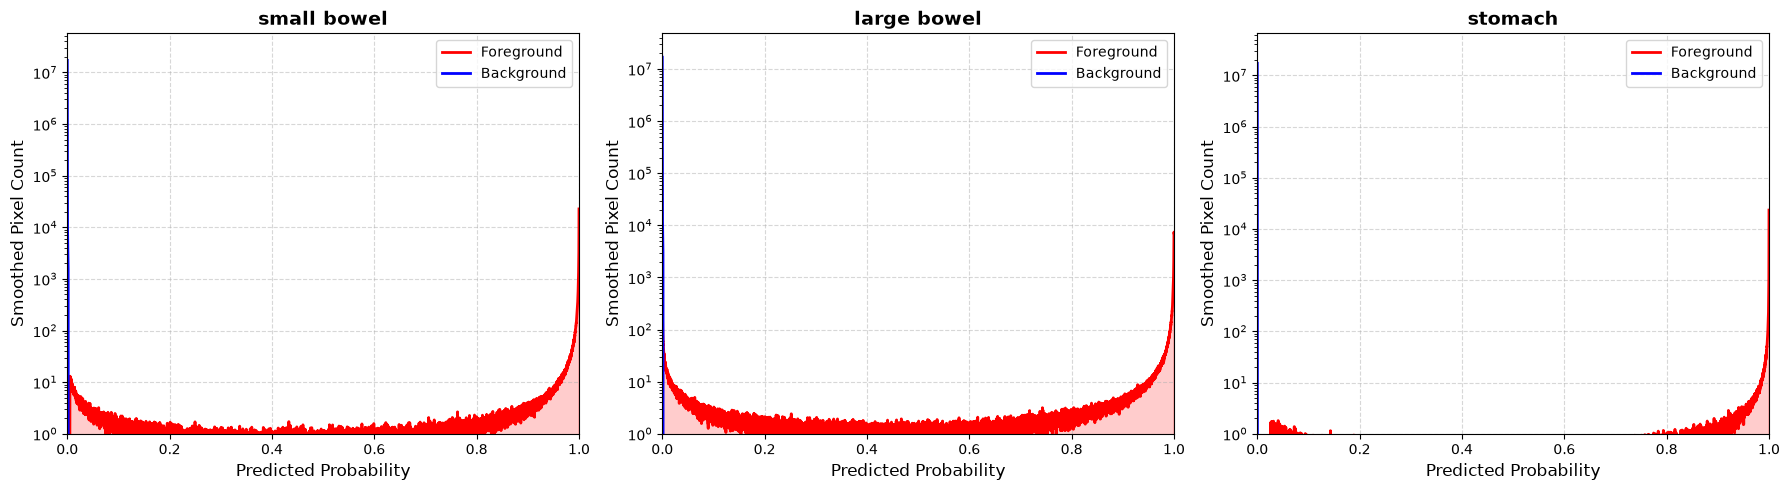

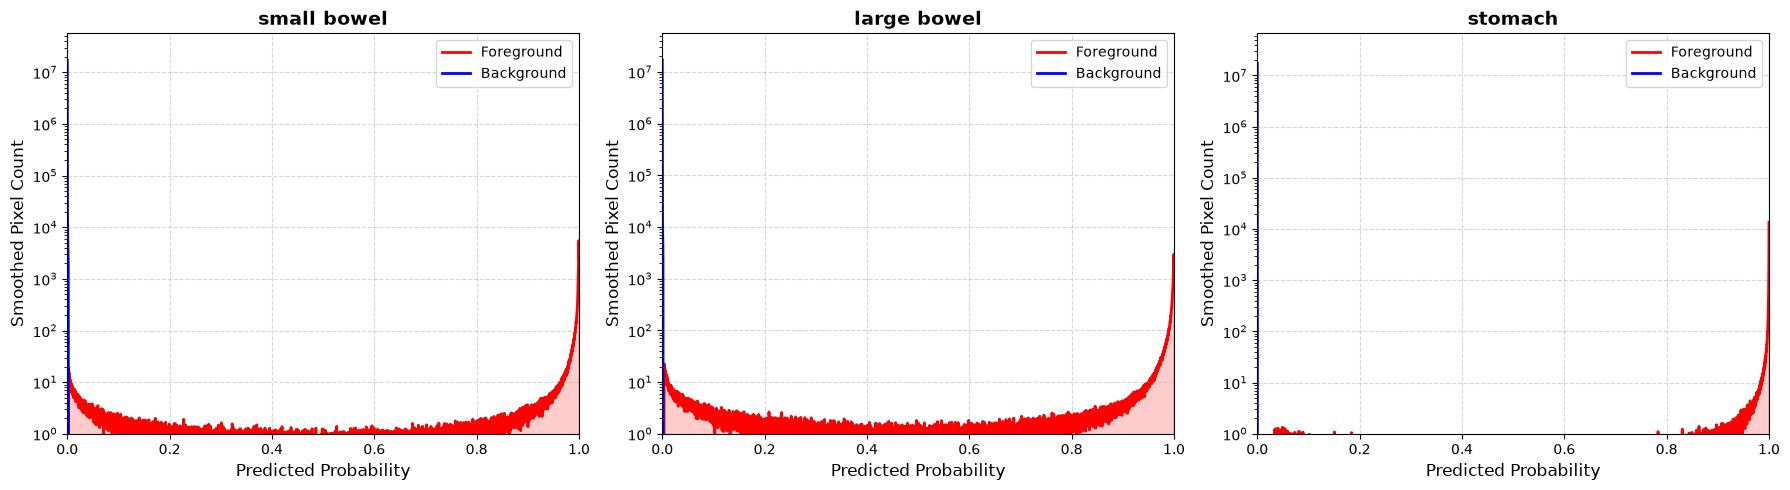

In [280]:
#plot_smooth_distributions(get_partial_distribution(dist_pos, ratio = [0.96,0.955,0.98]),   get_partial_distribution(dist_neg, neg_arr=True, ratio = [0.96,0.955,0.98]))
plot_smooth_distributions(get_partial_distribution(dist_pos_2, ratio = [0.98312722, 0.97371935, 0.96375511]), get_partial_distribution(dist_neg_2, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511]), 5, 0, 1)
plot_smooth_distributions(get_partial_distribution(dist_pos_3, ratio = [0.98312722, 0.97371935, 0.96375511]), get_partial_distribution(dist_neg_3, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511]),5, 0, 1)
#plot_smooth_distributions(get_partial_distribution(dist_pos_4, ratio = [0.96,0.955,0.98]), get_partial_distribution(dist_neg_4, neg_arr=True, ratio = [0.96,0.955,0.98]))
#plot_smooth_distributions(get_partial_distribution(dist_pos_5, ratio = [0.96,0.955,0.98]), get_partial_distribution(dist_neg_5, neg_arr=True, ratio = [0.96,0.955,0.98]))

In [253]:
def find_intersection(pos_dist, neg_dist, steps = 10,lr = 5, early_stopping = False):
    ratio = np.array([0.96,0.94,0.965])
    best_diff = np.array([float('inf'),float('inf'),float('inf')])
    best_ratio = ratio
    best_trial = np.zeros(3, int)
    best_optim_threshold = np.zeros(3)
    for i in range(steps):
        pos_part_dist = get_partial_distribution(pos_dist, ratio = ratio)
        neg_part_dist = get_partial_distribution(neg_dist, neg_arr = True,ratio = ratio)
        
        pos_under_dist = np.sum(pos_part_dist != 0 , 1) 
        neg_under_dist = np.sum(neg_part_dist != 0 , 1)

        diff = len(pos_dist[0]) - pos_under_dist - neg_under_dist
        diff = np.array(diff)
        abs_diff = abs(diff)
        optim_threshold = (len(pos_dist[0]) - pos_under_dist - diff//2)/len(pos_dist[0])
        better = abs_diff < abs(best_diff)

        best_diff[better] = diff[better]
        best_ratio[better] = ratio[better]
        best_trial[better] = i
        best_optim_threshold[better] = optim_threshold[better]
        print('='*20)
        print(*[
            f'''\n----------------------------------------
            \nbest difference for {c}th channel 
            \nfalls under {best_ratio[c]*100}% distribution 
            \nrecorded at {best_trial[c]} 
            \nwith difference of {best_diff[c]} 
            ''' for c in range(len(better))])

        if early_stopping and np.sum(better)==0: 
            break

        ratio+= diff/np.sum(pos_dist, 1)*lr

    return best_ratio, best_diff, best_trial, best_optim_threshold


In [210]:
arr = len(dist_pos_3[0]) - np.sum(get_partial_distribution(dist_pos_3) != 0 , 1) - np.sum(get_partial_distribution(dist_neg_3, neg_arr=True) != 0 , 1)
arr / np.sum(dist_pos , 1) 

array([0.00042653, 0.00049696, 0.00195926])

In [191]:
np.sum(get_partial_distribution(dist_pos_3), 1)/np.sum(dist_pos_3, 1), np.sum(get_partial_distribution(dist_neg_3, neg_arr=True),1)/np.sum(dist_neg_3, 1)

(array([0.96001729, 0.94000397, 0.96502747]),
 array([0.96696828, 0.95457195, 0.97673166]))

In [194]:
get_partial_distribution(dist_neg_3, neg_arr=True) != 0

array([[ True,  True, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False]], shape=(3, 10001))

In [197]:
(dist_neg_3[:, 0] + dist_neg_3[:, 1])/np.sum(dist_neg_3, 1)

array([0.96696828, 0.96161991, 0.9864801 ])

In [254]:
arr, _, _, thresh = find_intersection(dist_pos_3, dist_neg_3, 500, 3)


----------------------------------------
            
best difference for 0th channel 
            
falls under 96.0% distribution 
            
recorded at 0 
            
with difference of 365.0 
             
----------------------------------------
            
best difference for 1th channel 
            
falls under 94.0% distribution 
            
recorded at 0 
            
with difference of 423.0 
             
----------------------------------------
            
best difference for 2th channel 
            
falls under 96.5% distribution 
            
recorded at 0 
            
with difference of 746.0 
            

----------------------------------------
            
best difference for 0th channel 
            
falls under 96.12795867927946% distribution 
            
recorded at 1 
            
with difference of 332.0 
             
----------------------------------------
            
best difference for 1th channel 
            
falls under 94.1490883756886% dist

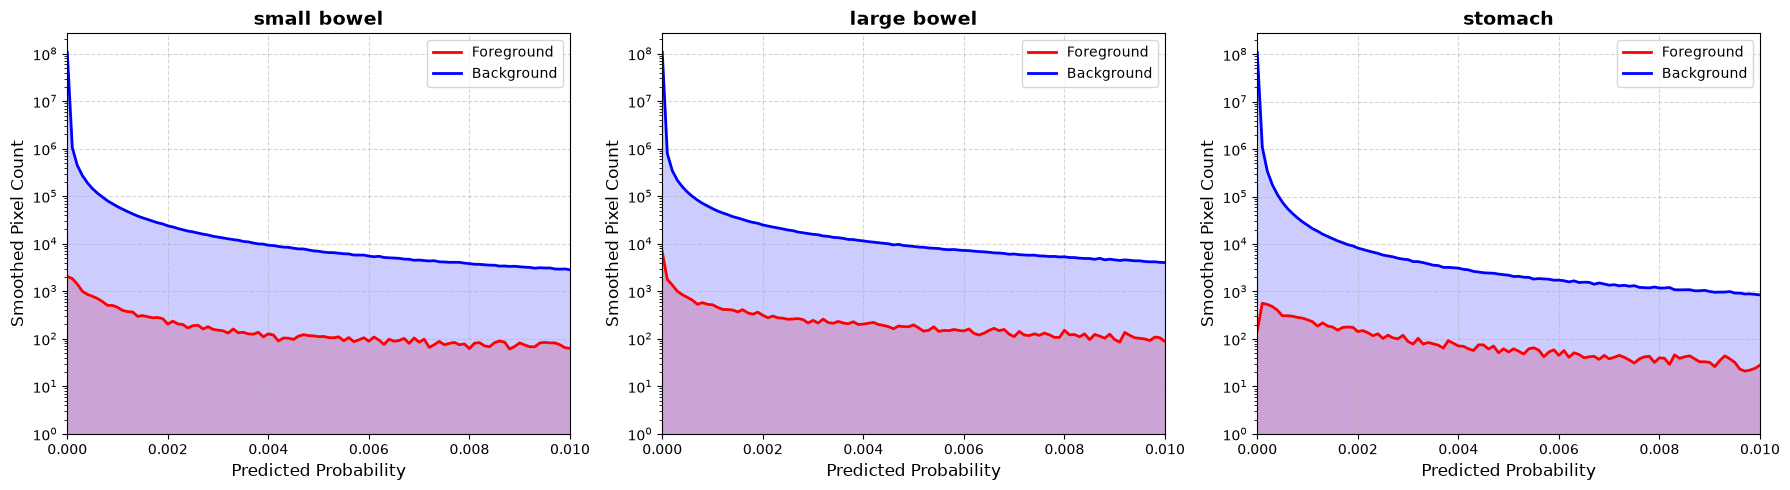

In [262]:
plot_smooth_distributions(get_partial_distribution(dist_pos_3 ), get_partial_distribution(dist_neg_3, neg_arr=True ), 0)


In [ ]:
get_partial_distribution(dist_pos_3, ratio = [0.98312722, 0.97371935, 0.96375511])/ np.sum(dist_pos_3), get_partial_distribution(dist_neg_3, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511])/np.sum(dist_neg_3,1)

In [ ]:
np.sum(get_partial_distribution(dist_pos_3, ratio = [0.98312722, 0.97371935, 0.96375511]) == 0, 1)#/np.sum(dist_pos_3, 1), 
#10001-np.sum(get_partial_distribution(dist_neg_3, neg_arr=True, ratio = [0.98312722, 0.97371935, 0.96375511])==0,1)#/np.sum(dist_neg_3, 1)

array([ 28,  34, 797])

In [255]:
thresh

array([0.00249975, 0.00249975, 0.04819518])

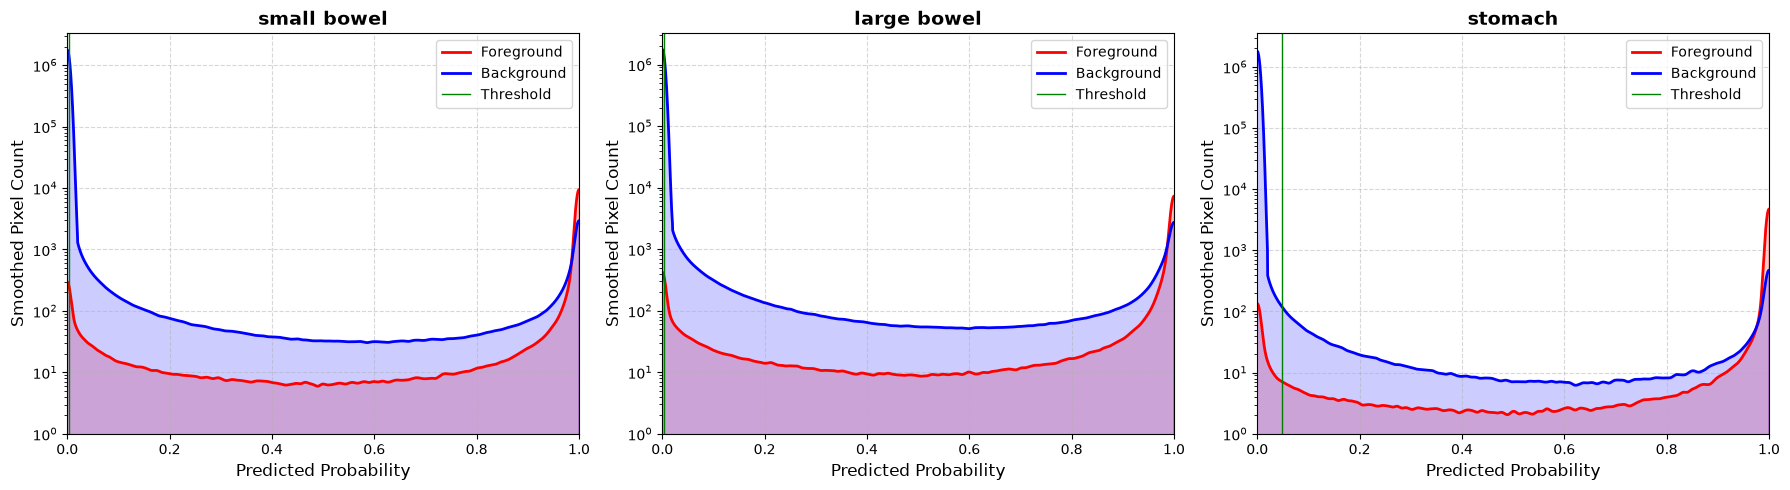

In [264]:
plot_smooth_distributions(dist_pos_3, dist_neg_3, threshold = thresh)

In [ ]:
#! wrap with more global function to pass only checkpoint path instead model
#! how should balance pos and neg
class ThresholdCalibrator:
    def __init__(self, model, dataloader, device, num_integ_bins = 100001):
        self.model = model
        self.dataloader = dataloader
        self.device = device 
        self.num_integ_bins = num_integ_bins
        self.dist_pos = None
        self.dist_neg = None
        self.best_ratio = np.array([0.96,0.94,0.965])
        self.best_trial = None
        self.best_threshold = None


    def get_distribution(self):

        num_channels = 3

        dist_pos = np.zeros((num_channels, self.num_integ_bins), dtype=np.int64)  
        dist_neg = np.zeros((num_channels, self.num_integ_bins), dtype=np.int64)  

        self.model.eval()
        with torch.no_grad():
            for i, batch in enumerate(dataloader):
                inp, mask = batch
                out = torch.sigmoid(self.model(inp))  

                for c in range(num_channels):
                    probs_c = out[:, c].reshape(-1)
                    mask_c = mask[:, c].reshape(-1)

                    pos_vals = probs_c[mask_c == 1]
                    neg_vals = probs_c[mask_c == 0]

                    pos_bins = (pos_vals * (self.num_integ_bins-1)).round().type(torch.int64).cpu().numpy()
                    neg_bins = (neg_vals * (self.num_integ_bins-1)).round().type(torch.int64).cpu().numpy()

                    dist_pos[c] += np.bincount(pos_bins, minlength=self.num_integ_bins)
                    dist_neg[c] += np.bincount(neg_bins, minlength=self.num_integ_bins)
                print(i)

        self.dist_pos, self.dist_neg = dist_pos, dist_neg



    def plot_smooth_distributions(self, dist_pos = None, dist_neg = None, sigma=50, left_x_lim = 0, right_x_lim = 1, threshold = None):

        if not dist_pos:
            dist_pos = np.copy(self.dist_pos)

        if not dist_neg:
            dist_neg = np.copy(self.dist_neg)
        x = np.linspace(0, 1, self.num_integ_bins)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        channel_names = ['small bowel', 'large bowel', 'stomach']
        
        for c in range(3):
            ax = axes[c]
            if sigma == 0:
                smooth_pos = dist_pos[c].astype(float)
                smooth_neg = dist_neg[c].astype(float)

            else:
                smooth_pos = gaussian_filter1d(dist_pos[c].astype(float), sigma=sigma)
                smooth_neg = gaussian_filter1d(dist_neg[c].astype(float), sigma=sigma)
            
            ax.plot(x, smooth_pos, label='Foreground', color='red', linewidth=2)
            ax.plot(x, smooth_neg, label='Background', color='blue', linewidth=2)
            if threshold is not None:
                ax.axvline(x = threshold[c], label = 'Threshold', color = 'green', linewidth = 1)
            
            ax.fill_between(x, smooth_pos, alpha=0.2, color='red')
            ax.fill_between(x, smooth_neg, alpha=0.2, color='blue')
            
            ax.set_title(f'{channel_names[c]}', fontsize=14, fontweight='bold')
            ax.set_xlabel('Predicted Probability', fontsize=12)
            ax.set_ylabel('Smoothed Pixel Count', fontsize=12)
            
            ax.set_yscale('log')
            ax.set_xlim(left_x_lim, right_x_lim)
            
            ax.set_ylim(bottom=1) 
            
            ax.grid(True, linestyle='--', alpha=0.5)
            ax.legend(loc='best')
            
        plt.tight_layout()
        plt.show()



    def min_max_norm(self,arr):
        pass




    def get_partial_distribution(self, neg_arr = False, ratio = [1,1,1]):

        ratio = np.array(ratio)
        if neg_arr:
            part_dist = np.copy(self.dist_neg)
        else:
            part_dist = np.copy(self.dist_pos)
        lengths = np.sum(part_dist, axis=1)
        amounts_to_discard = np.round(lengths * ([1] - ratio))
        
        if neg_arr:
            part_dist = np.flip(part_dist, 1)
        cum_sums = np.cumsum(part_dist, axis=1)
        mask_to_zero = cum_sums <= amounts_to_discard[:, None]
        
        part_dist[mask_to_zero] = 0
        if neg_arr:
            part_dist = np.flip(part_dist, 1)
        return part_dist



    def find_intersection(self, steps = 10, lr = 5, early_stopping = False):
        if self.best_ratio is not None:
            ratio = self.best_ratio
        else:
            ratio = np.array([0.5,0.5,0.5])
        best_diff = np.array([float('inf'),float('inf'),float('inf')])
        best_ratio = ratio
        if self.best_trial is not None:
            best_trial = self.best_trial
        else:
            best_trial = np.zeros(3, int) 
        if self.best_trial is not None:
            best_threshold = self.best_treshold
            best_threshold = np.zeros(3)
        for i in range(steps):
            pos_part_dist = self.get_partial_distribution(ratio = ratio)
            neg_part_dist = self.get_partial_distribution(neg_arr = True,ratio = ratio)
            
            pos_under_dist = np.sum(pos_part_dist != 0 , 1) 
            neg_under_dist = np.sum(neg_part_dist != 0 , 1)

            diff = self.num_integ_bins - pos_under_dist - neg_under_dist
            diff = np.array(diff)
            abs_diff = abs(diff)
            optim_threshold = (self.num_integ_bins - pos_under_dist - (diff//2 or maybe 0))/self.num_integ_bins
            better = abs_diff < abs(best_diff)

            best_diff[better] = diff[better]
            best_ratio[better] = ratio[better]
            best_trial[better] = i
            best_threshold[better] = optim_threshold[better]
            print('='*20)
            print(*[
                f'''\n----------------------------------------
                \nbest difference for {c}th channel 
                \nfalls under {best_ratio[c]*100}% distribution 
                \nrecorded at {best_trial[c]} 
                \nwith difference of {best_diff[c]} 
                ''' for c in range(len(better))])

            if early_stopping and np.sum(better)==0: 
                break

            ratio+= diff/np.sum(self.dist_pos, 1)*lr

        self.best_ratio = best_ratio 
        self.best_diff = best_diff 
        self.best_trial = best_trial 
        self.best_threshold = best_threshold

        
